# Notebook 2 : Exploratory Data Analysis (EDA) 

In this notebook, we will analyze the data of our asset (TICKER=AAPL). We will focus particularly on the distribution of its daily returns (searching for normality and asymmetry), the study of rolling volatility to delineate market regimes, as well as an exploratory correlation matrix of our primary technical indicators.

To better understand our data and its underlying patterns, we will perform an Exploratory Data Analysis (EDA) focused on the following key aspects:

**1. Global Trends & Price Action**
- Adjusted closing prices evolution of the given TICKER over time.
- Simple Moving Averages (SMA) to identify macro trends (20-day, 50-day, and 100-day).

**2. Return Distributions**
- Daily returns distribution (histogram and density plots).
- Kurtosis and Skewness analysis to identify non-normal behaviors and "fat tails" (extreme market events).

**3. Volatility**
- Rolling volatility to detect market regimes (calm vs. crisis periods).
- Bollinger Bands to visualize price divergence and mean reversion thresholds.

**4. Volume vs. Price Analysis**
- Daily trading volume.
- Relationship between volume spikes and significant upward/downward price movements.

**5. Correlation Analysis**
- Correlation Heatmap to detect multicollinearity among our predictive variables.
- Feature-to-Target correlation to identify which technical indicators have the highest predictive power for upcoming returns.




# 1 Global Trends & Price Action

In this part we will : 
- Plot Adjusted closing prices evolution of the given TICKER over time.
- Plot Simple Moving Averages (SMA) to identify macro trends (20-day, 50-day, and 200-day).

First, we need to extract our data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

try:
    base_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    current_dir = os.getcwd()
    base_dir = os.path.dirname(current_dir)
if base_dir not in sys.path:
    sys.path.append(base_dir)
    
from helpers import csv_file as cf

df = cf.loadcsv()
print(df.head())




Data already exists in /Volumes/LaCie/bourse/CAC40_Stock_market_Prediction/data/AAPL_2024.csv. Loading locally...
         Date        Open        High         Low       Close    AdjClose  \
0  2024-01-02  187.149994  188.440002  183.889999  185.639999  183.731308   
1  2024-01-03  184.220001  185.880005  183.429993  184.250000  182.355606   
2  2024-01-04  182.149994  183.089996  180.880005  181.910004  180.039673   
3  2024-01-05  181.990005  182.759995  180.169998  181.179993  179.317154   
4  2024-01-08  182.089996  185.600006  181.500000  185.559998  183.652145   

     Volume  
0  82488700  
1  58414500  
2  71983600  
3  62379700  
4  59144500  


### 1.1 Adjusted Closing price

No we plot the Adjusted Closing price for the period : 

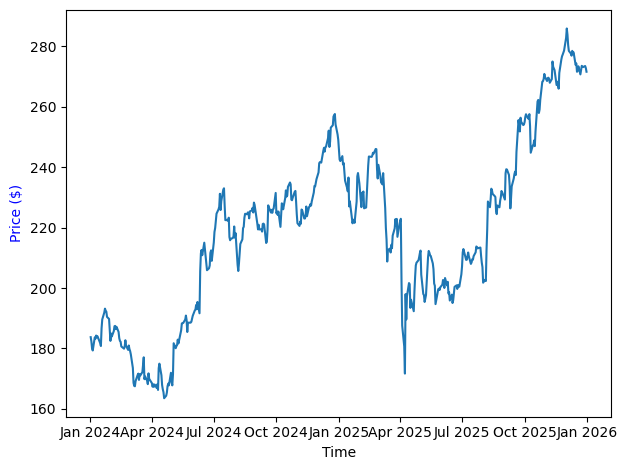

In [ ]:
import matplotlib.dates as mdates
df["Date"] = pd.to_datetime(df["Date"])
x = df["Date"]
y = df["AdjClose"]

plt.xlabel("Time", )
plt.ylabel("Price ($)", color="blue")
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.plot(x,y)
plt.tight_layout()
plt.show()
plt.savefig('02_AdjClose.png')

We observe several points :

- Firstly, out curb evolve between 170$ and 290$.

The minimum global was reached on May 2025 during the ... crisis which has destabilized stock market.

The maximum was reached on December 2026 because of the ...

### 1.2 Simple Moving Average (20 days, 50 days, 200 days)

The objective of these 3 curbs is to understand the tendances and to go further in the understanding of the value

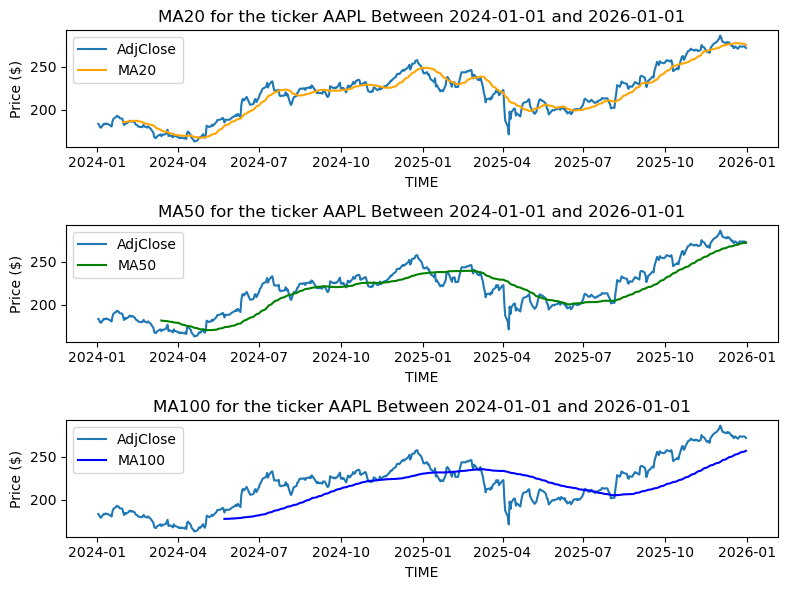

<Figure size 640x480 with 0 Axes>

In [ ]:
df["MA20"] = df["AdjClose"].rolling(20).mean()
df["MA50"] = df["AdjClose"].rolling(50).mean()
df["MA100"] = df["AdjClose"].rolling(100).mean()

fig, axs = plt.subplots(3, 1, figsize=(8, 6))

mas = [df["MA20"], df["MA50"], df["MA100"]]
labels = ["MA20", "MA50", "MA100"]
colors = ["orange", "green", "blue"]

for i, ax in enumerate(axs):
    ax.plot(x, df["AdjClose"], label="AdjClose")
    ax.plot(x, mas[i], label=labels[i], color=colors[i])
    ax.set_title(f"{labels[i]} for the ticker {cf.TICKER} Between {cf.START} and {cf.END}")
    ax.set_xlabel("TIME")
    ax.set_ylabel("Price ($)")
    ax.legend()

plt.tight_layout()
plt.show()
plt.savefig('02_SMA.png')

We observe that SMA remove the noises, we could predict tendances, the action value tends to increase during 2 two years passing approximately from 150$ to 290. 
We see that the deep dive on May 2025 is completely ponctual, and didn't impact the SMA 100.

## 2. Return Distributions


### 2.1 Daily returns distribution (histogram and density plots).

To better understand daily returns, we will observe 1,2 and 10 days returns.
It will gives us information on the daily volatility but also...

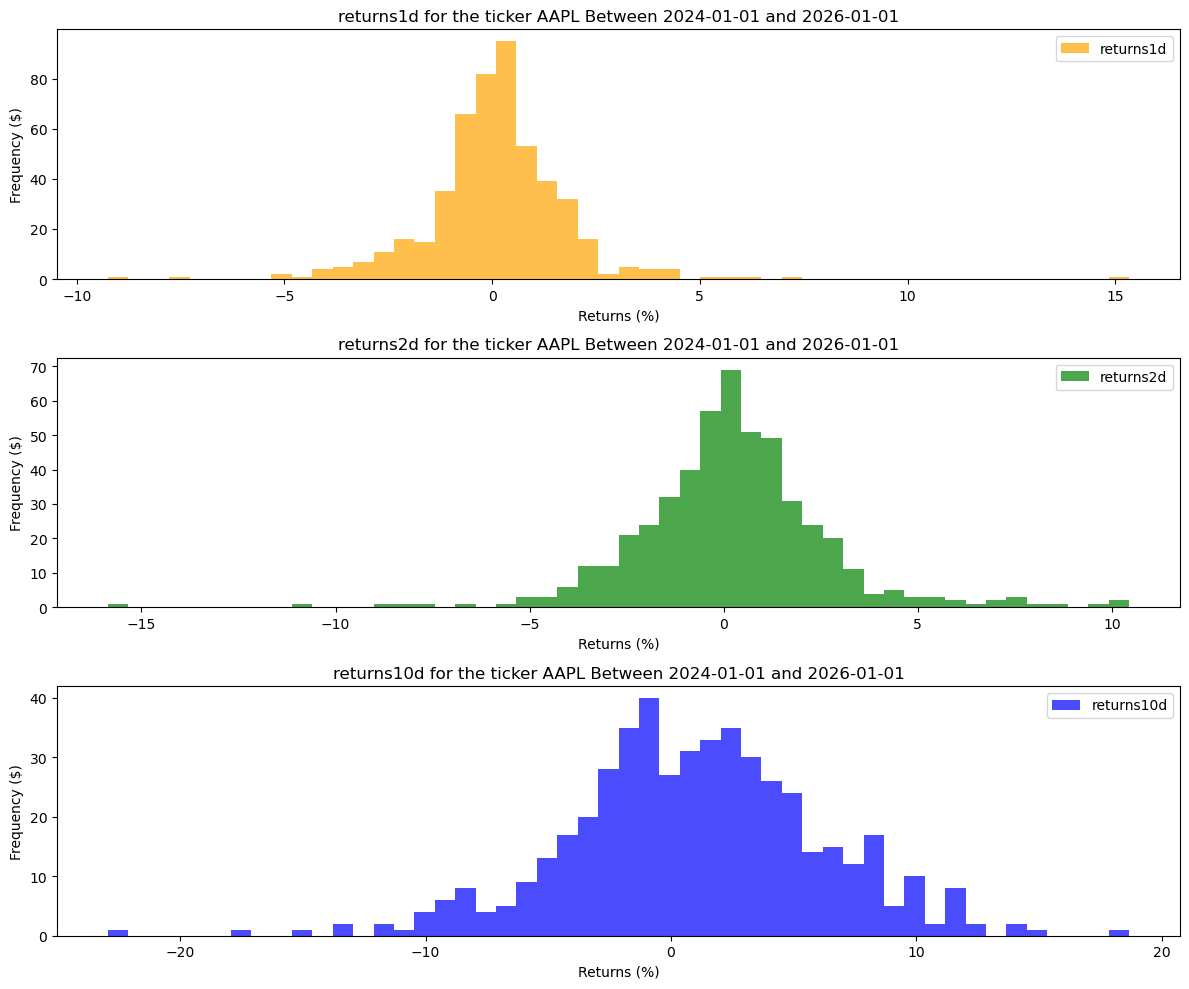

In [ ]:

df["returns1d"] = df["AdjClose"].pct_change() * 100 # compare with former value
df["returns2d"] = df["AdjClose"].pct_change(2) * 100
df["returns10d"] = df["AdjClose"].pct_change(10) * 100

fig, axs = plt.subplots(3, 1, figsize=(12, 10))

mas = [df["returns1d"], df["returns2d"], df["returns10d"]]
labels = ["returns1d", "returns2d", "returns10d"]
colors = ["orange", "green", "blue"]

for i, ax in enumerate(axs):
    ax.hist(mas[i].dropna(), bins=50, label=labels[i], color=colors[i], alpha=0.7)
    ax.set_title(f"{labels[i]} for the ticker {cf.TICKER} Between {cf.START} and {cf.END}")
    ax.set_xlabel("Returns (%)")
    ax.set_ylabel("Frequency ($)")
    ax.legend()

plt.tight_layout()
plt.show()
plt.savefig('02_returns_hist.png')

Except outliers, we observe that daily and 2 days, values varient between -3%, 3% the curb looks like a gaussean centered in 0 for all period (except 10 days which is less proper).
Moreover 10 days returns varient beetwen -5% to 5% except outliers which is interesting.

2.2